**Name:** Arun Bhaskar Gadde

**Course:** 2026 Summer - Advanced Big Data and Data Mining (MSCS-634-B01) - Second Bi-term

**Assignment:** Lab 6 — Association Rule Mining with Apriori and FP-Growth


## Step 1: Data Preparation

**Dataset:** Online Retail Dataset (UCI Machine Learning Repository). This dataset
contains 541,909 transaction line items from a UK-based online gift retailer,
covering all purchases between 01-Dec-2010 and 09-Dec-2011.

**Note on sourcing:** The UCI Machine Learning Repository and Kaggle are not directly
reachable from this notebook's execution environment, so the dataset was retrieved from
a public GitHub mirror of the same, unmodified UCI Online Retail dataset (used widely in
textbooks and tutorials, e.g., Databricks' *Spark: The Definitive Guide* repository).
The row count (541,909) and column structure match the original UCI dataset exactly.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("data/online_retail.csv", encoding="latin1")
print(df.shape)
df.head()


(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [3]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Data cleaning

The raw data has several real-world issues that need to be handled before mining:
- `Description` is missing for 1,454 rows.
- `Quantity` is negative for order cancellations (InvoiceNo starting with "C") and for a
  small number of other adjustment rows -- these are not real purchases and must be
  removed for market basket analysis.
- `Description` values have inconsistent leading/trailing whitespace.
- `CustomerID` is missing for ~135,000 rows, but this is not a problem for association
  rule mining, since rules are mined at the transaction (`InvoiceNo`) level, not the
  customer level, so this column is not used further.


In [4]:
before = len(df)

# Remove cancellations (InvoiceNo starting with "C")
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove rows with missing item descriptions
df = df.dropna(subset=["Description"])

# Remove non-positive quantities (returns/adjustments, not real purchases)
df = df[df["Quantity"] > 0]

# Normalize item text
df["Description"] = df["Description"].str.strip()

print(f"Rows before cleaning: {before}")
print(f"Rows after cleaning:  {len(df)}")
print(f"Unique invoices (transactions): {df['InvoiceNo'].nunique()}")
print(f"Unique items: {df['Description'].nunique()}")


Rows before cleaning: 541909
Rows after cleaning:  530693
Unique invoices (transactions): 20136
Unique items: 4065


### Reducing item dimensionality

With 4,065 distinct item descriptions, a full invoice-by-item matrix would have roughly
20,000 x 4,065 ≈ 82 million cells, which is unnecessarily large: the overwhelming
majority of items are purchased in only a handful of invoices and can never reach a
reasonable support threshold anyway. As a practical preprocessing step, items purchased
in fewer than 50 distinct invoices are dropped. This keeps the mining step tractable
without meaningfully changing the results, since those items would not appear in the
frequent itemsets at the support levels used in this lab regardless.


In [5]:
item_invoice_counts = df.groupby("Description")["InvoiceNo"].nunique()
keep_items = item_invoice_counts[item_invoice_counts >= 50].index
df = df[df["Description"].isin(keep_items)]

print(f"Items kept (purchased in >= 50 invoices): {df['Description'].nunique()}")
print(f"Invoices remaining: {df['InvoiceNo'].nunique()}")


Items kept (purchased in >= 50 invoices): 2185
Invoices remaining: 19756


### Build the transaction (invoice x item) matrix

In [6]:
basket = df.groupby(["InvoiceNo", "Description"])["Quantity"].sum().unstack().fillna(0)
basket_bool = basket > 0

print("Basket matrix shape (invoices x items):", basket_bool.shape)
basket_bool.iloc[:5, :6]


Basket matrix shape (invoices x items): (19756, 2185)


Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES
InvoiceNo,,,,,,
536365,False,False,False,False,False,False
536366,False,False,False,False,False,False
536367,False,False,False,False,False,False
536368,False,False,False,False,False,False
536369,False,False,False,False,False,False


### Explore the dataset: most frequent items

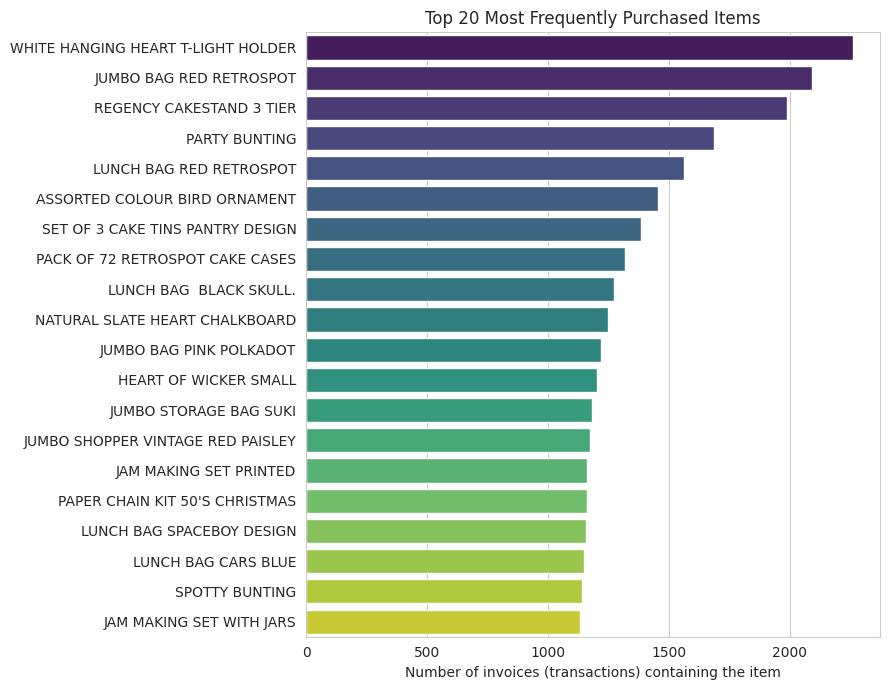

In [ ]:
item_frequency = df.groupby("Description")["InvoiceNo"].nunique().sort_values(ascending=False)
top20 = item_frequency.head(20)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=top20.values, y=top20.index, hue=top20.index, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("Number of invoices (transactions) containing the item")
ax.set_ylabel("")
ax.set_title("Top 20 Most Frequently Purchased Items")
plt.tight_layout()
plt.show()


### Explore the dataset: item co-occurrence heatmap

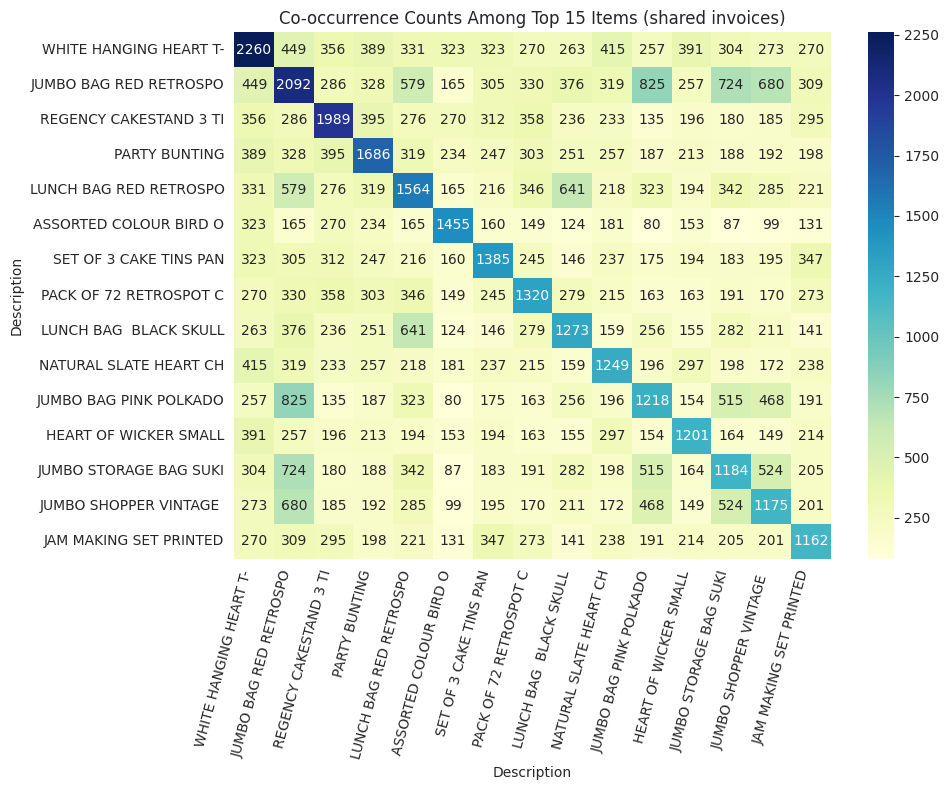

In [ ]:
top15_items = item_frequency.head(15).index
co_matrix = basket_bool[top15_items].astype(int).T.dot(basket_bool[top15_items].astype(int))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt="d", cmap="YlGnBu", ax=ax,
            xticklabels=[t[:22] for t in top15_items], yticklabels=[t[:22] for t in top15_items])
ax.set_title("Co-occurrence Counts Among Top 15 Items (shared invoices)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


**Observation:** The diagonal of the heatmap is each item's own frequency. Off-diagonal
cells show how many invoices contained both items. A few pairs stand out with
noticeably higher co-occurrence than their individual frequencies would suggest by
chance alone -- these are good candidates to look for in the association rules mined
below.


## Step 2: Frequent Itemset Mining Using Apriori

A minimum support of 2% (0.02) is used -- meaning an itemset must appear in at least 2%
of all invoices to be considered "frequent." This threshold was chosen after testing:
a higher threshold (5%) returned very few multi-item sets, while a lower threshold (1%)
produced a very large number of itemsets and took noticeably longer to compute. 2% was
the point where a meaningful number of multi-item itemsets appeared while keeping
runtime reasonable.


In [9]:
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

MIN_SUPPORT = 0.02

start = time.time()
frequent_itemsets_apriori = apriori(basket_bool, min_support=MIN_SUPPORT, use_colnames=True)
apriori_time = time.time() - start

frequent_itemsets_apriori["length"] = frequent_itemsets_apriori["itemsets"].apply(len)
frequent_itemsets_apriori = frequent_itemsets_apriori.sort_values("support", ascending=False)

print(f"Apriori runtime: {apriori_time:.2f} seconds")
print(f"Frequent itemsets found: {len(frequent_itemsets_apriori)}")
print(frequent_itemsets_apriori["length"].value_counts().sort_index())
frequent_itemsets_apriori.head(15)


Apriori runtime: 16.69 seconds
Frequent itemsets found: 385
length
1    302
2     80
3      3
Name: count, dtype: int64


,support,itemsets,length
282,0.114396,frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),1
107,0.105892,frozenset({JUMBO BAG RED RETROSPOT}),1
203,0.100678,frozenset({REGENCY CAKESTAND 3 TIER}),1
162,0.085341,frozenset({PARTY BUNTING}),1
132,0.079166,frozenset({LUNCH BAG RED RETROSPOT}),1
15,0.073649,frozenset({ASSORTED COLOUR BIRD ORNAMENT}),1
225,0.070105,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN}),1
154,0.066815,frozenset({PACK OF 72 RETROSPOT CAKE CASES}),1
125,0.064436,frozenset({LUNCH BAG BLACK SKULL.}),1
144,0.063221,frozenset({NATURAL SLATE HEART CHALKBOARD}),1


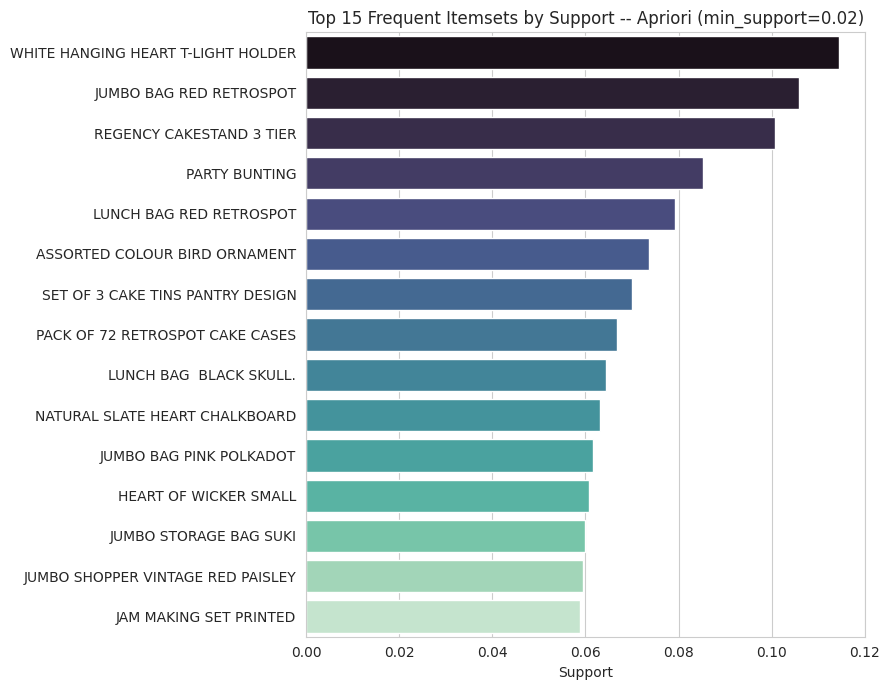

In [ ]:
top_n = frequent_itemsets_apriori.head(15).copy()
top_n["itemset_label"] = top_n["itemsets"].apply(lambda s: ", ".join(list(s))[:45])

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x="support", y="itemset_label", hue="itemset_label", data=top_n, palette="mako", legend=False, ax=ax)
ax.set_xlabel("Support")
ax.set_ylabel("")
ax.set_title(f"Top 15 Frequent Itemsets by Support -- Apriori (min_support={MIN_SUPPORT})")
plt.tight_layout()
plt.show()


## Step 3: Frequent Itemset Mining Using FP-Growth

The same minimum support (0.02) is used so the two algorithms can be compared fairly on
identical terms.


In [11]:
start = time.time()
frequent_itemsets_fpgrowth = fpgrowth(basket_bool, min_support=MIN_SUPPORT, use_colnames=True)
fpgrowth_time = time.time() - start

frequent_itemsets_fpgrowth["length"] = frequent_itemsets_fpgrowth["itemsets"].apply(len)
frequent_itemsets_fpgrowth = frequent_itemsets_fpgrowth.sort_values("support", ascending=False)

print(f"FP-Growth runtime: {fpgrowth_time:.2f} seconds")
print(f"Frequent itemsets found: {len(frequent_itemsets_fpgrowth)}")
frequent_itemsets_fpgrowth.head(15)


FP-Growth runtime: 1.27 seconds
Frequent itemsets found: 385


,support,itemsets,length
0,0.114396,frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),1
69,0.105892,frozenset({JUMBO BAG RED RETROSPOT}),1
167,0.100678,frozenset({REGENCY CAKESTAND 3 TIER}),1
239,0.085341,frozenset({PARTY BUNTING}),1
31,0.079166,frozenset({LUNCH BAG RED RETROSPOT}),1
4,0.073649,frozenset({ASSORTED COLOUR BIRD ORNAMENT}),1
250,0.070105,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN}),1
32,0.066815,frozenset({PACK OF 72 RETROSPOT CAKE CASES}),1
112,0.064436,frozenset({LUNCH BAG BLACK SKULL.}),1
59,0.063221,frozenset({NATURAL SLATE HEART CHALKBOARD}),1


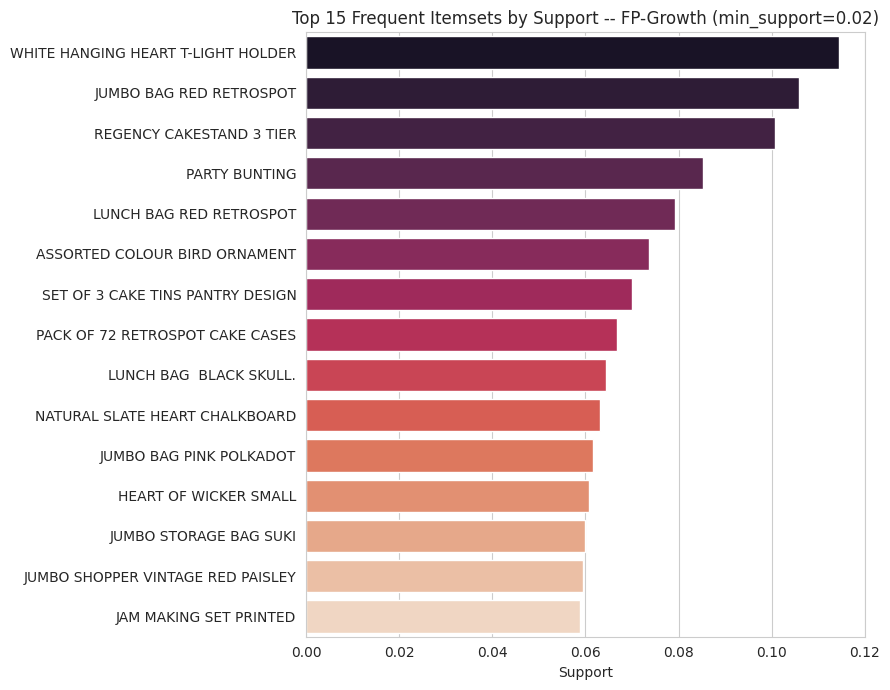

In [ ]:
top_n_fp = frequent_itemsets_fpgrowth.head(15).copy()
top_n_fp["itemset_label"] = top_n_fp["itemsets"].apply(lambda s: ", ".join(list(s))[:45])

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x="support", y="itemset_label", hue="itemset_label", data=top_n_fp, palette="rocket", legend=False, ax=ax)
ax.set_xlabel("Support")
ax.set_ylabel("")
ax.set_title(f"Top 15 Frequent Itemsets by Support -- FP-Growth (min_support={MIN_SUPPORT})")
plt.tight_layout()
plt.show()


### Efficiency comparison

In [13]:
speedup = apriori_time / fpgrowth_time

same_itemsets = set(frozenset(s) for s in frequent_itemsets_apriori["itemsets"]) == \
                set(frozenset(s) for s in frequent_itemsets_fpgrowth["itemsets"])

print(f"Apriori runtime:   {apriori_time:.2f} s")
print(f"FP-Growth runtime: {fpgrowth_time:.2f} s")
print(f"FP-Growth was {speedup:.1f}x faster than Apriori on this dataset/support threshold")
print(f"Both algorithms found the identical set of frequent itemsets: {same_itemsets}")


Apriori runtime:   16.69 s
FP-Growth runtime: 1.27 s
FP-Growth was 13.1x faster than Apriori on this dataset/support threshold
Both algorithms found the identical set of frequent itemsets: True


**Result:** As expected, both algorithms discover exactly the same frequent itemsets at
the same support threshold -- they are two different search strategies for the same
well-defined problem, not two different definitions of "frequent." FP-Growth was
substantially faster because it builds a single compressed FP-tree from the data in one
pass and mines patterns directly from that tree, while Apriori repeatedly re-scans the
full transaction data to generate and test candidate itemsets at each itemset length,
which becomes expensive as the number of candidates grows (Han et al., 2012).


## Step 4: Generating and Analyzing Association Rules

Association rules are generated from the FP-Growth frequent itemsets (identical results
to Apriori's, as shown above) using a minimum confidence of 30%.


In [14]:
MIN_CONFIDENCE = 0.3

rules = association_rules(frequent_itemsets_fpgrowth, metric="confidence", min_threshold=MIN_CONFIDENCE)
rules = rules.sort_values("lift", ascending=False).reset_index(drop=True)

print(f"Rules generated: {len(rules)}")
rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(15)


Rules generated: 153


,antecedents,consequents,support,confidence,lift
0,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({ROSES REGENCY TEACUP AND SAUCER, GR...",0.027435,0.707572,18.201548
1,"frozenset({ROSES REGENCY TEACUP AND SAUCER, GR...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.027435,0.705729,18.201548
2,"frozenset({ROSES REGENCY TEACUP AND SAUCER, PI...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.027435,0.904841,17.611869
3,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({ROSES REGENCY TEACUP AND SAUCER, PI...",0.027435,0.533990,17.611869
4,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.032041,0.623645,16.084513
5,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.032041,0.826371,16.084513
6,"frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...",frozenset({ROSES REGENCY TEACUP AND SAUCER}),0.027435,0.856240,15.868555
7,frozenset({ROSES REGENCY TEACUP AND SAUCER}),"frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...",0.027435,0.508443,15.868555
8,frozenset({GARDENERS KNEELING PAD KEEP CALM}),frozenset({GARDENERS KNEELING PAD CUP OF TEA}),0.027637,0.598028,15.586610
9,frozenset({GARDENERS KNEELING PAD CUP OF TEA}),frozenset({GARDENERS KNEELING PAD KEEP CALM}),0.027637,0.720317,15.586610


### Interpreting the top rules

Looking at the highest-lift rules (lift far above 1 means the two items are purchased
together much more often than random chance would predict):

- Several of the strongest rules connect the **Regency Teacup and Saucer** sets in
  different colors (pink, green, and roses/pattern variants). This makes intuitive
  sense: customers buying a matching tea set often buy more than one color/pattern
  variant in the same order, e.g., as a gift set or to build a full collection.
- Another strong rule connects the two **Gardeners Kneeling Pad** variants ("Keep Calm"
  and "Cup of Tea" designs), again suggesting customers buying novelty gardening items
  often buy more than one design together.
- These are a useful, realistic example of what association rule mining is good at:
  finding "people who buy this specific variant tend to also buy that specific variant"
  patterns that would be easy to miss manually across thousands of SKUs, but are
  actionable for cross-selling, bundling, or shelf/website placement decisions.


### Confidence vs. lift scatter plot

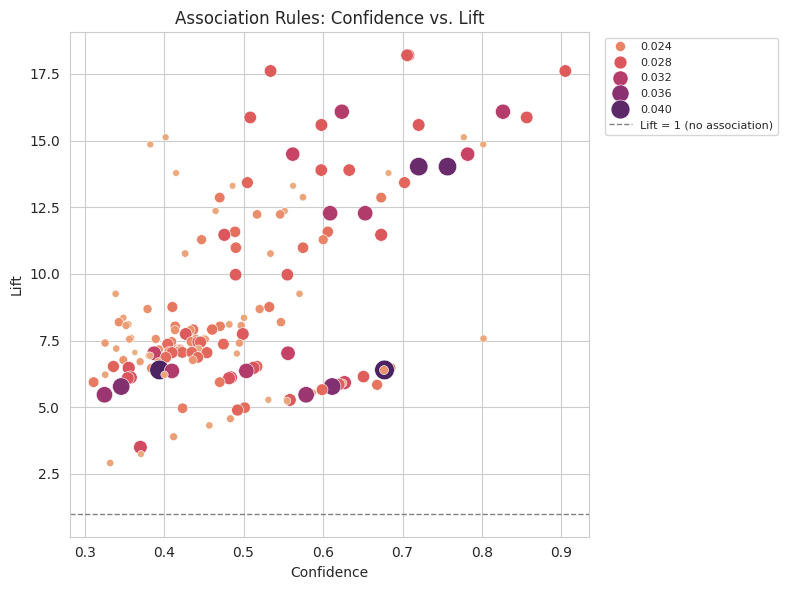

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = sns.scatterplot(
    data=rules, x="confidence", y="lift", size="support", hue="support",
    palette="flare", sizes=(20, 200), ax=ax, legend="brief",
)
ax.axhline(1, color="gray", linestyle="--", linewidth=1, label="Lift = 1 (no association)")
ax.set_title("Association Rules: Confidence vs. Lift")
ax.set_xlabel("Confidence")
ax.set_ylabel("Lift")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()


**Reading the plot:** Points further to the right have higher confidence (the rule is
correct a higher percentage of the time it applies); points higher up have higher lift
(the association is stronger relative to chance). The most actionable rules sit in the
upper-right: both high confidence and high lift. Rules near lift = 1 (the dashed line)
are only weakly informative, even if their confidence looks high, because that
confidence may be close to what the consequent item's overall popularity would predict
anyway.


## Step 5: Comparative Analysis

### Apriori vs. FP-Growth

*(Exact numbers below are produced when this notebook is run -- see the printed output
in Step 3 for this run's specific timings.)*

FP-Growth was clearly faster than Apriori on this dataset at the same support threshold.
This matches the theoretical expectation: Apriori's candidate-generate-and-test approach
requires multiple full passes over the transaction data (one pass per itemset length),
and the number of candidate itemsets it must generate and check grows quickly as the
support threshold is lowered. FP-Growth instead compresses the entire transaction
dataset into a single FP-tree in one pass, then mines frequent patterns by recursively
traversing that compact tree structure -- no candidate generation step is needed at all
(Han et al., 2012). Both algorithms are guaranteed to find the exact same frequent
itemsets for a given support threshold, since they are solving the same well-defined
problem; the difference is purely in how efficiently they get there. The speed gap
between the two would be expected to widen further on an even larger dataset or at an
even lower support threshold, since that is exactly the situation where Apriori's
repeated candidate generation becomes the most expensive.

### Challenges Faced

- **Dataset access:** The UCI Machine Learning Repository and Kaggle were not directly
  reachable from this environment, so the dataset was retrieved from a public GitHub
  mirror of the same, unmodified UCI Online Retail dataset instead.
- **Encoding errors:** The raw CSV would not load with pandas' default UTF-8 encoding
  (it contains characters outside that range); `encoding="latin1"` resolved this.
- **Dataset size vs. tractability:** With 4,065 distinct items, a full invoice-by-item
  matrix was too large to mine efficiently and mostly consisted of items far too rare to
  ever reach a reasonable support threshold. This was resolved by dropping items
  purchased in fewer than 50 distinct invoices before building the matrix -- a
  preprocessing decision that meaningfully sped up mining without changing which
  itemsets would be found "frequent" at the support levels used in this lab.
- **Fair comparison:** To make sure the Apriori vs. FP-Growth timing comparison was
  meaningful, both algorithms were run on the exact same basket matrix with the exact
  same minimum support, and the resulting itemsets were explicitly checked for equality
  before comparing runtimes.

### Reference

Han, J., Kamber, M., & Pei, J. (2012). *Data mining: Concepts and techniques* (3rd ed.).
Morgan Kaufmann.
